Bibliotecas que se ocuparan:

In [40]:
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import norm
import yfinance as yf
import pandas as pd
import numpy as np

<h1 style="text-align: center; color: green;">Temas selectos de Riesgo de Financiero</h1>

### Practica 2 Métodos del VaR

#### Value at Risk (VaR)


El valor en riesgo (Value at Risk) es una medida de riesgo de mercado que responde a la siguiente pregunta:

"Cual es la pérdidad máxima esperada de una inversión, en un periodo de tiempo dado, con un cierto nivel de confianza?"

<div style="text-align:center">
    <img src="https://www.glynholton.com/wp-content/uploads/2013/06/value-at-risk-1.png" width="400">
</div>


$$VaR α,T = {x ∈ ℜ | [Pr(pérdida en T) > x] = α}.$$

Formalmente el VaR es un nivel de pérdidas tal, que la probabilidad “α” de que la pérdida exceda esta cantidad en un periodo de tiempo dado, corresponde a un cierto nivel de confianza escogido para el análisis.

Puntos clave:
- Se fija un horizonte temporal (por ejemplo, Var de un 1 dia)
- Se fija un nivel de confianza( 95% o 99% de confianza)
- El VaR es un número monetario que resuemen el riesgo.


Ejemplo

  > Si el VaR diaria (es decir Var de un 1 día) al 95% de una acción es de $20,000, significa que en 95 de cada 100 días la perdida no superará $20,000.

En el 5% restante, la perdida puede ser mayor"


Existen varias metodologías para realizar el el cálculo del VaR, algunas que veremos serán:

1. Historico
1. Parámetro
1. Simulación de Monte Carlo

#### Desarrollo
Descargar los precios reales de una empresa:

In [41]:
ticker = "LABB.MX"   # Cambiar por acciones de una empresa mexicana

In [42]:
# Obtenemos la fecha y hora actual
ahora = datetime.now()

# Convertirmos el string con formato: DD/MM/YYYY
fecha_hoy = ahora.strftime("%Y-%m-%d")

print(fecha_hoy)  # Salida: 18/02/2026

2026-03-06


In [43]:
# Descargamos la historia de nuestras acciones
data = yf.download(ticker, start="2022-01-01", end=fecha_hoy, auto_adjust=False)
data

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,LABB.MX,LABB.MX,LABB.MX,LABB.MX,LABB.MX,LABB.MX
Date,,,,,,
2022-01-03,18.025366,21.350000,21.530001,21.219999,21.480000,757853
2022-01-04,17.907167,21.209999,21.549999,21.100000,21.350000,7927879
2022-01-05,17.628553,20.879999,21.400000,20.410000,21.200001,1606320
2022-01-06,17.814297,21.100000,21.370001,20.510000,20.910000,1168959
2022-01-07,17.577894,20.820000,21.150000,20.600000,20.719999,834128
...,...,...,...,...,...,...
2026-02-27,18.280001,18.280001,18.500000,17.600000,17.660000,4381771
2026-03-02,17.760000,17.760000,18.219999,17.620001,18.129999,4385071


| Columna   | Significado     | Descripción                                                                                                                 |
|-----------|-----------------|-----------------------------------------------------------------------------------------------------------------------------|
| Open      | Apertura        | El precio al que cotizaba el activo cuando abrió el mercado ese día.                                                        |
| High      | Máximo          | El precio más alto alcanzado durante la sesión de trading.                                                                  |
| Low       | Mínimo          | El precio más bajo registrado en ese día.                                                                                   |
| Close     | Cierre          | El precio final al que se negoció el activo cuando cerró el mercado.                                                        |
| Adj Close | Cierre Ajustado | La más importante para análisis. Es el precio de cierre modificado para incluir dividendos y repartos de acciones (splits). |
| Volume    | Volumen         | La cantidad total de unidades (acciones o contratos) que cambiaron de manos ese día.                                        |


In [44]:
data["Adj Close"]

Ticker,LABB.MX
Date,
2022-01-03,18.025366
2022-01-04,17.907167
2022-01-05,17.628553
2022-01-06,17.814297
2022-01-07,17.577894
...,...
2026-02-27,18.280001
2026-03-02,17.760000
2026-03-03,17.580000


In [45]:
data.columns = data.columns.get_level_values(0) # Esto elimina el nivel extra del Ticker
print(data['Adj Close'])

Date
2022-01-03    18.025366
2022-01-04    17.907167
2022-01-05    17.628553
2022-01-06    17.814297
2022-01-07    17.577894
                ...    
2026-02-27    18.280001
2026-03-02    17.760000
2026-03-03    17.580000
2026-03-04    17.670000
2026-03-05    17.700001
Name: Adj Close, Length: 1049, dtype: float64


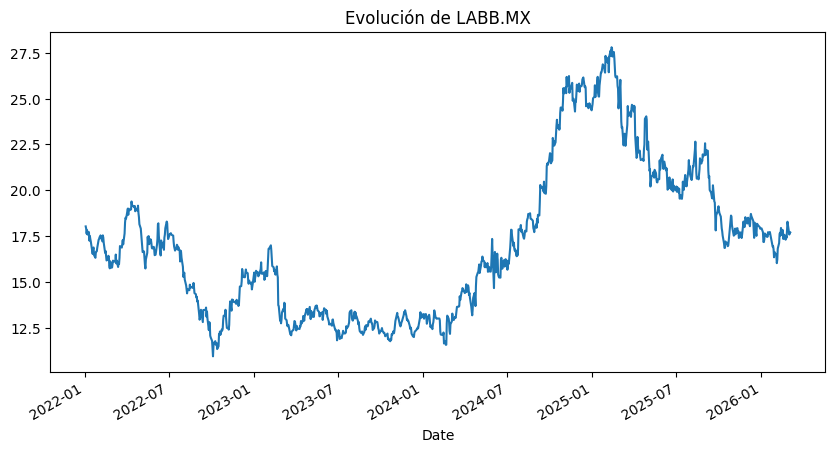

In [46]:
data['Adj Close'].plot(figsize=(10, 5), title=f"Evolución de {ticker}")
plt.show()

__Análiza el comportamiento de los precios de tu empresa y responde las siguientes preguntas:__
1. ¿¿Predomina una tendencia alcista, bajista o lateral?

Se ve algo mas Lateral con ciclos a largo plazo, ya que por un momento es super alsista , pero en otros es mas bajista y luego se mantiene en subir y bajar  

2. ¿Cuál es el precio mínimo histórico de la acción en el periodo analizado?

In [47]:
precio_minimo = data['Adj Close'].min()
print(f'El precio minimo de la accion de {ticker} es {precio_minimo}')

El precio minimo de la accion de LABB.MX es 10.936185836791992


3. ¿Cuál es el precio máximo histórico de la acción en el periodo analizado?

In [48]:
precio_maximo = data['Adj Close'].max()
print(f'El precio maximo de la accion de {ticker} es {precio_maximo}')

El precio maximo de la accion de LABB.MX es 27.800710678100586


4. ¿Cuál es el valor promedio de las acciones?

In [49]:
precio_promedio = data['Adj Close'].mean()
print(f'El precio promedio de la accion de {ticker} es {precio_promedio}')

El precio promedio de la accion de LABB.MX es 17.02480811272722


5. ¿Por qué mirando el precio de las acciones no te permite evaluar el riesgo?

Por que el precio muestra cuánto vale, mientras que el riesgo depende de cuánto y cómo cambia ese valor en el tiempo

### Rendimientos

El retorno o rendimiento financiero es una forma de medir la ganancia o pérdida generada en una inversión en relación con la cantidad de dinero que has invertido.

> El riesgo está en el movimiento.

Vamos a tener 2 tipos de retornos:

- Retorno simple
- Retorno logaritmo


Convertimos nuesetros precios diarios en rendimientos porcentuales, que es lo que usamos para medir riesgo y calcular VaR.


In [50]:
prices = data["Adj Close"]
prices

Date
2022-01-03    18.025366
2022-01-04    17.907167
2022-01-05    17.628553
2022-01-06    17.814297
2022-01-07    17.577894
                ...    
2026-02-27    18.280001
2026-03-02    17.760000
2026-03-03    17.580000
2026-03-04    17.670000
2026-03-05    17.700001
Name: Adj Close, Length: 1049, dtype: float64

In [51]:
returns = np.log(prices / prices.shift(1)).dropna()
returns.head()

Date
2022-01-04   -0.006579
2022-01-05   -0.015681
2022-01-06    0.010481
2022-01-07   -0.013359
2022-01-10    0.007656
Name: Adj Close, dtype: float64

Nuestro función `prices.shift(1)`nos ayuda a realizar el rezago de un día para realizar cambio entre precio hoy con el precio anterior.

| Día | Precio | Precio anterior |
| --- | ------ | --------------- |
| 1   | 100    | NaN             |
| 2   | 102    | 100             |
| 3   | 101    | 102             |


Cambio relativo

$$ \frac{Precio_{hoy}}{Precio_{ayer}}$$

Ejemplo:

• Día 2 → 102 / 100 = 1.02


• Día 3 → 101 / 102 = 0.990

Esto nos dice:

👉 cuánto creció o cayó en proporción


Para el retorno logaritmico tomamos el logaritmo natural:

$$ r_t = ln(\frac{Precio_{hoy}}{Precio_{ayer}})$$

Las ventajas de realizar esta operación son las siguientes:

- Se suma fácilmente en el tiempo.
- Es estándar en finanzas cuantitativas.
- Aproxima bien retornos pequeños.


Ejemplo:

Si sube 2%:

$ln (1.02) ≈ 0.0198$



Esta línea convierte precios diarios en rendimientos porcentuales (logarítmicos), que es lo que usamos para medir riesgo y calcular VaR.

**Retorno simple**

In [52]:
# También se puede usar retorno simple utilizando la función que viene por defecto en python:
returns = prices.pct_change().dropna()
returns

Date
2022-01-04   -0.006557
2022-01-05   -0.015559
2022-01-06    0.010537
2022-01-07   -0.013270
2022-01-10    0.007685
                ...   
2026-02-27    0.027544
2026-03-02   -0.028446
2026-03-03   -0.010135
2026-03-04    0.005119
2026-03-05    0.001698
Name: Adj Close, Length: 1048, dtype: float64

El retorno simple se define como:

$$R = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Donde:

$P_t = \text{Precio en el tiempo t}$

$P_{t-1} = \text{Precio en el tiempo } t-1$

Ejemplo:

| Día | Precio | Precio anterior |
| --- | ------ | --------------- |
| 1   | 100    | NaN             |
| 2   | 110    | 100             |


$R = \frac{110 - 100}{100} = 0.1 = 10\%$





Para periodos cortos, retorno simple ≈ retorno log.

$r= ln(\frac{110}{100}) = ln(1.10)=0.0953$


Pero en finanzas cuantitativas se prefiere log por propiedades matemáticas.


__Son aditivos en el tiempo__.

Ejemplo: Si iniciamos con un activo que vale 100$  y sube +10% y despues +10%, la manera de calcularlo seria:


Como aumento +10 tendriamos 110:

$$100 + 100 * (0.1) = 110 = 100 * (1+0.1)$$

Ahora subimos nuevamente +10% de los 110 que teniamos

$$ 110 + 110 * (0.1) = 121 = 110 * (1+0.1)$$


Precio inicial = 100

Precio final = 121


Si realizamos todo en un paso seria:

$$P_{i}=100$$
$$P_f = 121 = 110 * (1+0.1) $$
$$P_f = 100 * (1+0.1) * (1+0.1) = P_i * (1+r) * (1+r)$$


Recordemos nuestra formula de retorno simple:
$$R = \frac{P_t - P_{t-1}}{P_{t-1}}$$


$$R = \frac{P_i * (1+r) * (1+r) - P_{i}}{P_{i}}$$

$$R = (1+r) * (1+r) - 1$$
$$ = (1+0.1) * (1+0.1) - 1  = 0.21 = 21\%$$


Ahora con retorno log:


$$ r_t = ln(\frac{Precio_{hoy}}{Precio_{ayer}})$$


$$ r_t = ln(\frac{P_i * (1+r) * (1+r)}{P_i})$$

$$ r_t = ln({(1+r) * (1+r)})$$

Por propiedades de los logartimos podemos separara la multiplicación:

$$ r_t = ln(1+r) + ln(1+r)$$
$$ r_t = ln(1+0.1) + ln(1+0.1)$$
$$ r_t = ln(1.1) + ln(1.1)$$
$$r_t = ln(1.21)$$


Con esto vemos que son aditivos en el tiempo gracias a las propiedades de los logaritmos, el cual hace que las operaciones se simplifiquen.

__Regresando a nuestro retornos, responde las siguientes preguntas:__
1. Muestra la distribución de los rendimientos obtenidos de tu empresa.

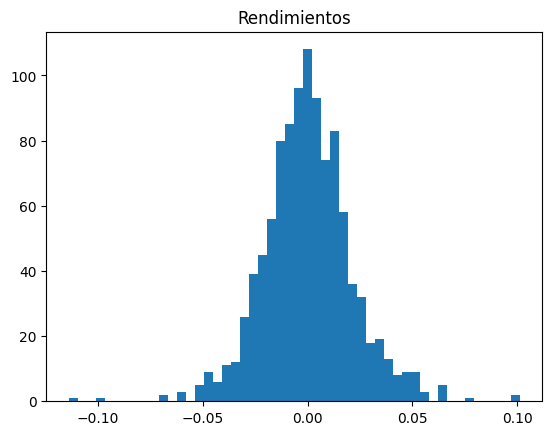

In [53]:
import matplotlib.pyplot as plt

plt.hist(returns, bins=50)
plt.title("Rendimientos")
plt.show()

2. ¿Cuál fue el peor retorno?

In [54]:
peor_retorno = returns.min()
print(f"El peor retorno registrado es: {peor_retorno}")

El peor retorno registrado es: -0.11405979702190594


3. ¿Cuál fue el mejor retorno retorno?

In [55]:
mejor_retorno = returns.max()
print(f"El mejor retorno registrado es: {mejor_retorno}")

El mejor retorno registrado es: 0.10119530548160838


4. ¿Presentan asimetría?

Asimetría por columna:
0.08592462252352669


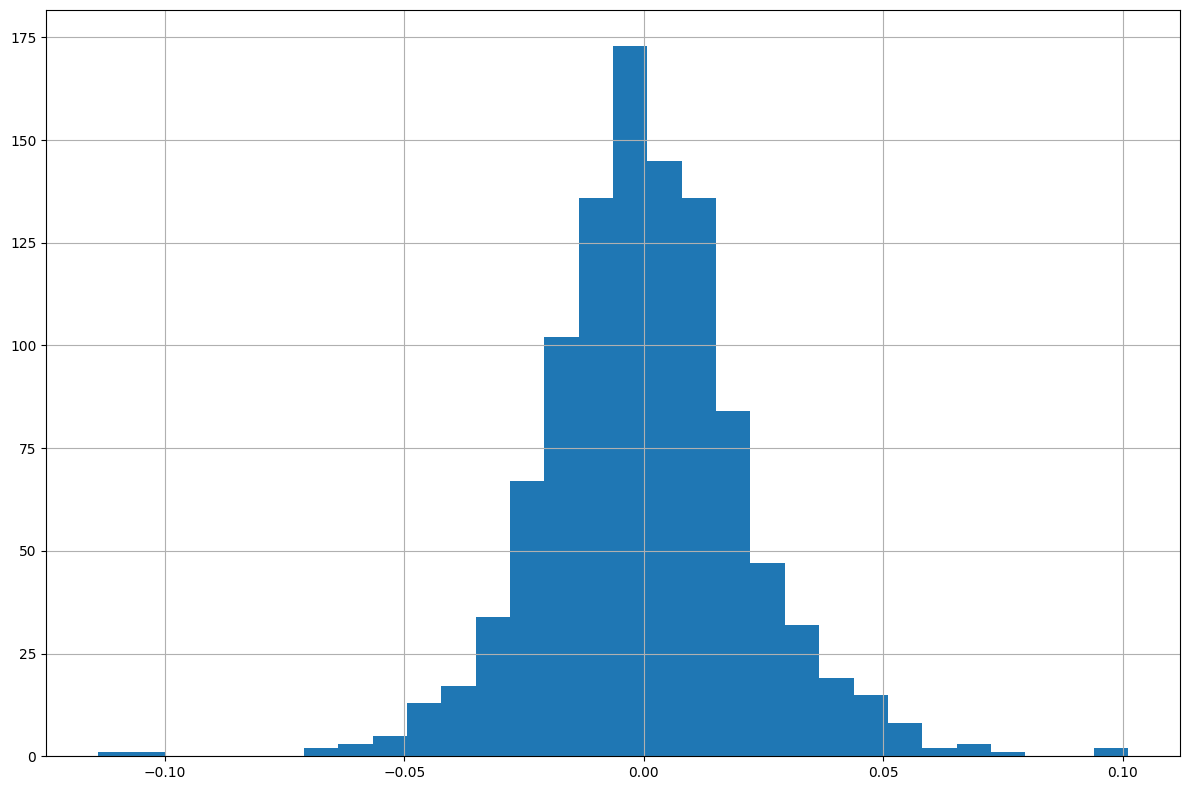

In [56]:
print("Asimetría por columna:")
print(returns.skew())

returns.hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

Como la asimetria esta muy cercana a cero , nos dice que no hay una asimetria fuerte . Ademas como es positiva , esto nos dice que la cola derecha apenas es un poco mas larga que la de la izquierda

5. ¿La curtosis sugiere colas pesadas?

In [57]:
print("Curtosis por columna:")
print(returns.kurtosis())

Curtosis por columna:
2.3133454801142967


Su curtosis de 2.3133 es positiva y relativamente alta, es decir, tiene colas más pesadas y mayor probabilidad de valores extremos que una distribución normal

6. ¿Existen outliers claros en la historia de rendimientos?

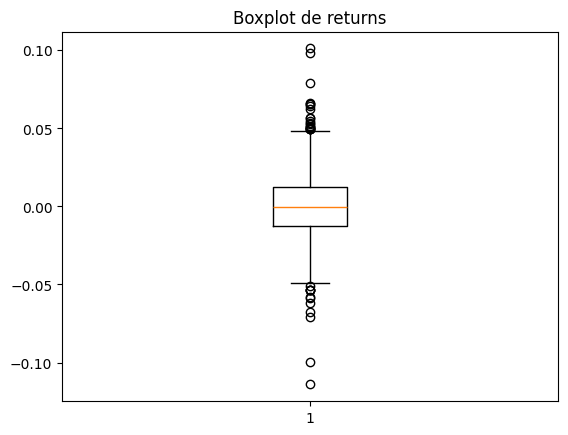

In [58]:
plt.boxplot(returns.dropna())
plt.title("Boxplot de returns")
plt.show()

Si existen muchos outliers, como podemos evr los puntos fuera de de los bigotes del boxplot

### VaR Histórico

- Usa el pasado real para estimar el peor escenario “normal”.


- Tomas retornos diarios reales (ej. de Apple)

- Los ordenas del peor al mejor

- Buscas el 5% peor (si usas 95% confianza)



In [59]:
# Se definir los siguientes parametros:
inversion = 10000               # La cantidad que vas invertir.
nivel_confianza = 0.95          # El nivel de confianza que quieres obtener.

In [60]:
# Para obtener nuestro percentil, que será aquell donde tendriamos uno de los peores rendimientos,
# tendremos que ordenar nuestro rendimientos.
# returns.sort_index(ascending=True) # Ordena por fecha
# Ordenamos del peor al mayor
# returns.sort_values()  # Ordena los rendimientos

# O usar la función np.percentile que internamente ordena la lista de valores que le pasemos y saca el percentil que definamos.
percentil = np.percentile(returns, (1 - nivel_confianza) * 100)
percentil

np.float64(-0.03142127767647901)

__Responde las siguientes preguntas:__
1. Muestra la distribución de los rendimientos y el percentil obtenido.

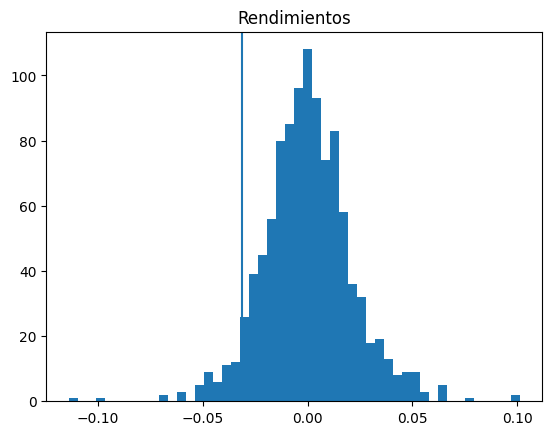

In [61]:
plt.hist(returns, bins=50)
plt.axvline(percentil)
plt.title("Rendimientos")
plt.show()

In [62]:
VaR = inversion * abs(percentil)


print("\nPercentil:", percentil)
print("\nVaR histórico al 95%:", VaR)


Percentil: -0.03142127767647901

VaR histórico al 95%: 314.2127767647901


2. ¿Que significa ese percentil?

3. Calculá el VaR.

4. Comenta cual seria la interpretación del VaR para la empresa que seleccionaste

In [63]:
print(f"""
El VaR histórico al {nivel_confianza*100}% es: ${VaR:.2f}

Interpretación:
Existe un {(nivel_confianza)*100}% de confianza de que la pérdida
no excederá ${VaR:.2f} en un día.
""")


El VaR histórico al 95.0% es: $314.21

Interpretación:
Existe un 95.0% de confianza de que la pérdida
no excederá $314.21 en un día.



5. Si $100,000 invertidos ¿Cuál es el VaR en dinero?.

In [64]:
round(100000 * abs(percentil), 2)

np.float64(3142.13)

__Realiza:__
1. Cálcula el VaR para 10 días.
2. Describe tus resultado como interpretarías el VaR de 10 dias.

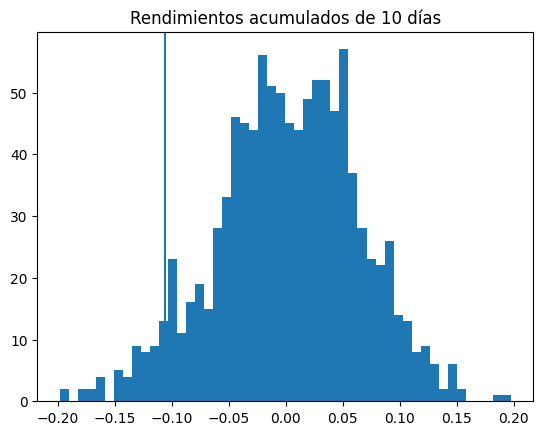

Percentil 10 días: -0.10618358627013905
VaR histórico de 10 días al 95%: $1061.84


In [65]:
# Parámetros
inversion = 10000
nivel_confianza = 0.95
returns_10d = returns.rolling(window=10).sum().dropna()

percentil_10d = np.percentile(returns_10d, (1 - nivel_confianza) * 100)
VaR_10d = inversion * abs(percentil_10d)

plt.hist(returns_10d, bins=50)
plt.axvline(percentil_10d)
plt.title("Rendimientos acumulados de 10 días")
plt.show()

print("Percentil 10 días:", percentil_10d)
print(f"VaR histórico de 10 días al {nivel_confianza*100:.0f}%: ${VaR_10d:.2f}")

Si el VaR de 10 días al 95% es de $1061.84, esto significa que, con 95% de confianza, la pérdida de la inversión en un periodo de 10 días no excederá  $1061.84.

### Simulación Historica


Para realizar la simulación historica tomamos el precio actual de la acción y se multiplicara con nuestros retornos obtenidos, con esto podría surgir la pregunta ¿Por qué se multiplica el último valor por cada retorno?

Y esto es porque estamos simulando:

    "¿Qué pasaría hoy si ocurriera cada retorno histórico?"

In [66]:
# Obtenemos el retorno simple
retornos = prices.pct_change().dropna()
retornos

Date
2022-01-04   -0.006557
2022-01-05   -0.015559
2022-01-06    0.010537
2022-01-07   -0.013270
2022-01-10    0.007685
                ...   
2026-02-27    0.027544
2026-03-02   -0.028446
2026-03-03   -0.010135
2026-03-04    0.005119
2026-03-05    0.001698
Name: Adj Close, Length: 1048, dtype: float64

In [67]:
# Obtenemos el último valor
valor_actual = retornos.iloc[-1]

# Multiplcamos el valor más actual con los retornos historicos.
valores_simulados = valor_actual * (1 + retornos)
valores_simulados

Date
2022-01-04    0.001687
2022-01-05    0.001671
2022-01-06    0.001716
2022-01-07    0.001675
2022-01-10    0.001711
                ...   
2026-02-27    0.001745
2026-03-02    0.001650
2026-03-03    0.001681
2026-03-04    0.001707
2026-03-05    0.001701
Name: Adj Close, Length: 1048, dtype: float64

Esto es una simulación histórica de posibles precios futuros.

Luego se calculan las pérdidas, las cuales se definene como:

$$Loss_i = P_{actual} - P_{simulado, i}$$

Donde:

$P_{actual}$ = Precio más reciente.

$- P_{simulado, 1}$ = Precio simultado en el tiempo $i$.

In [68]:
loss = valor_actual - valores_simulados
loss

Date
2022-01-04    0.000011
2022-01-05    0.000026
2022-01-06   -0.000018
2022-01-07    0.000023
2022-01-10   -0.000013
                ...   
2026-02-27   -0.000047
2026-03-02    0.000048
2026-03-03    0.000017
2026-03-04   -0.000009
2026-03-05   -0.000003
Name: Adj Close, Length: 1048, dtype: float64

Con sabemos cuanto perderiamos a traves de nuestra historia, para ver la cantidad que tendriamos con base a nuestro inversión multiplcamos la inversión por las perdidas.

In [69]:
inversion * loss

Date
2022-01-04    0.111333
2022-01-05    0.264162
2022-01-06   -0.178892
2022-01-07    0.225309
2022-01-10   -0.130476
                ...   
2026-02-27   -0.467643
2026-03-02    0.482972
2026-03-03    0.172078
2026-03-04   -0.086920
2026-03-05   -0.028826
Name: Adj Close, Length: 1048, dtype: float64

El VaR con simulación historica realmente mide:

$$VaR  = V_{actual} - V_{percentil}$$

la diferencia entre el valor actual y el peor escenario esperado.

In [70]:
# calcular percentil 5% para conocer nuestro peor escenario esperado.
percentil_5 = np.percentile(valores_simulados, 5)

In [71]:
# calcularmos VaR
VaR = valor_actual - percentil_5

print("VaR:", VaR * inversion)

VaR: 0.533480419639726


#### Metodo Paramétrico

Tienen como característica el supuesto de que los rendimientos de los activos se distribuyen de acuerdo con una curva de densidad de probabilidad, que generalmente es la normal y en el supuesto de linealidad en el valor de los activos.


$$𝑉𝑎𝑅=(𝜇−𝛼×𝜎)×𝑆×√𝑡.$$

Donde:

$𝜇:$   Media de los rendimientos del activo.

$σ:$   Desviación estándar de los rendimientos del activo.

$𝛼:$   Nivel de confianza del cálculo.

$S:$   Monto total de la inversión.

$t:$   Horizonte de tiempo.


En la practica la media suele ignorarse porque es muy pequeña.

In [72]:
# Calculos los rendimientos
returns = np.log(prices / prices.shift(1)).dropna()
returns.head()

Date
2022-01-04   -0.006579
2022-01-05   -0.015681
2022-01-06    0.010481
2022-01-07   -0.013359
2022-01-10    0.007656
Name: Adj Close, dtype: float64

In [73]:
# Definimos nuestros parametros
inversion = 10000
confidence_level = 0.95
mu = returns.mean()
sigma = returns.std()
horizonte_tiempo = 1
Z = norm.ppf(1-confidence_level) # Usamos la cola izquieda (perdidas)

print("Media diaria:", mu)
print("Volatilidad diaria:", sigma)
print("Z:", Z)

Media diaria: -1.7381007588016724e-05
Volatilidad diaria: 0.02130657913106163
Z: -1.6448536269514722


Z nos dice que tan lejos nos movemos jacoa la izquierda para cubrir cierto nivel de confianza.

Si usamos el 95% de confianza, signigica
  > Solo el 5% de los resultados estaran mas allá de 1.645 desviaciones estandar por debajo de la media.

In [74]:
# 7. Calcular VaR paramétrico
#VaR = Z * sigma * inversion
#VaR = (mu - Z * sigma) * inversion * np.sqrt(horizonte_tiempo)
VaR = (Z * sigma) * inversion * np.sqrt(horizonte_tiempo)
print(f"\nVaR paramétrico al 95%: ${VaR:.2f}")


VaR paramétrico al 95%: $-350.46


__1. Un inversionista tiene 35,000 acciones de tu empresa, ¿cuál es el VaR Paramétrico de su inversión a 10 día con un 5% de confianza?__

In [75]:
inversion = 10000 
from scipy.stats import norm

# Rendimientos logarítmicos
returns = np.log(prices / prices.shift(1)).dropna()

# Parámetros
confidence_level = 0.95
horizonte_tiempo = 10
num_acciones = 35000

# Precio actual de la acción
precio_actual = prices.iloc[-1]

# Valor de la inversión
inversion = num_acciones * precio_actual

# Parámetros de los rendimientos
mu = returns.mean()
sigma = returns.std()

# Percentil 5% de la normal estándar (cola izquierda)
Z = norm.ppf(1 - confidence_level)  

# VaR paramétrico a 10 días
VaR_10d = abs((mu * horizonte_tiempo + Z * sigma * np.sqrt(horizonte_tiempo)) * inversion)

print("Precio actual:", precio_actual)
print("Número de acciones:", num_acciones)
print("Valor de la inversión:", inversion)
print("Media diaria:", mu)
print("Volatilidad diaria:", sigma)
print("Z:", Z)
print(f"\nVaR paramétrico a 10 días: ${VaR_10d:.2f}")

Precio actual: 17.700000762939453
Número de acciones: 35000
Valor de la inversión: 619500.0267028809
Media diaria: -1.7381007588016724e-05
Volatilidad diaria: 0.02130657913106163
Z: -1.6448536269514722

VaR paramétrico a 10 días: $68764.28


### Simulación de MonteCarlo

El método Monte Carlo consiste en generar de manera aleatoria, escenarios de ocurrencia de los factores de riesgo que afectan el valor de los activos contenidos en un portafolio de activos financieros.

El método se resumen en:
- Generar miles de escenarios aleatorios.
- Simula posibles precios futuros.
- Cálcula pérdidas en cada escenarios.
- Se obtiene el percentil deseado.


El primer paso consiste en la selección de un proceso estocástico que modele el comportamiento del factor de riesgo. Comúnmente se utiliza el movimiento browniano geométrico, que en su forma discreta se puede escribir como:

 $$∆𝑆_𝑡=𝑆_{𝑡−1} (𝜇∆𝑡+𝜎𝜀√∆𝑡)$$


Donde:

$𝑆_𝑡:$ Precio al tiempo t.

$𝜇:$ Media de los precios.

$σ:$ Desviación estándar.

$𝜀:$ variable aleatoria normal estándar N(0,1).

$$∆𝑡=(𝑇−𝑡)/𝑛$$

Donde:

 $T:$ Es el horizonte de tiempo.

 $t:$ Fecha actual.

 $n:$ Tamaño del incremento.



In [76]:
# Calculamos redimientos logaritmos
returns = np.log(prices / prices.shift(1)).dropna()
returns.head()

Date
2022-01-04   -0.006579
2022-01-05   -0.015681
2022-01-06    0.010481
2022-01-07   -0.013359
2022-01-10    0.007656
Name: Adj Close, dtype: float64

In [77]:
# Calculamos los parametros
mu = returns.mean()
sigma = returns.std()
S0 = data["Adj Close"].iloc[-1] # Precio más reciente

print("Precio Actual", S0)
print("Media diaria: ", mu)
print("Volatilidad diaria:", sigma)

Precio Actual 17.700000762939453
Media diaria:  -1.7381007588016724e-05
Volatilidad diaria: 0.02130657913106163


In [78]:
T = 1                         # Horizonte 1 dia
N = 100000                    # Número de simulaciones
alpha= 0.95                   # Nivel de confianza
n = 100                        # Numero de pasos
t = 0                         # Paso inicial
dt = (T-t)/ n                 # Indica si vamos a simular con pasos grandes
z = np.random.normal(0, 1, N) # Simulación de variable aleatoria normal estandar N(0,1)

Si sumalamos 10 días en 10 pasos seria:

```{python}
T = 10
n = 10
dt = T/n
```

Si sumalamos 10 días en 100 pasos seria:

```{python}
T = 10
n = 100
dt = T/n
```

In [79]:
ST = S0 * mu*dt + sigma*z*np.sqrt(dt)
ST

array([ 0.00124081, -0.00076289, -0.00268574, ...,  0.00203569,
        0.00056906, -0.00186341], shape=(100000,))

In [80]:
# Calculamos las perdidas
losses = S0 - ST
losses

array([17.69875995, 17.70076366, 17.7026865 , ..., 17.69796507,
       17.6994317 , 17.70186417], shape=(100000,))

In [81]:
# Calculo del VaR

VaR = np.percentile(losses, alpha)
print("VaR Monte Carlo 95%:", VaR)

VaR Monte Carlo 95%: 17.69501996416308


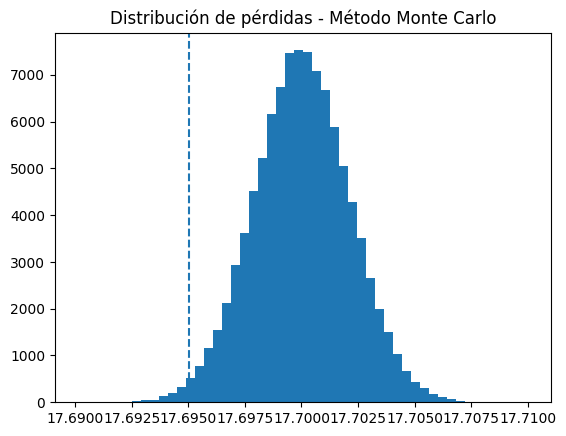

In [82]:
plt.hist(losses, bins=50)
plt.axvline(VaR, linestyle="dashed")
plt.title("Distribución de pérdidas - Método Monte Carlo")
plt.show()

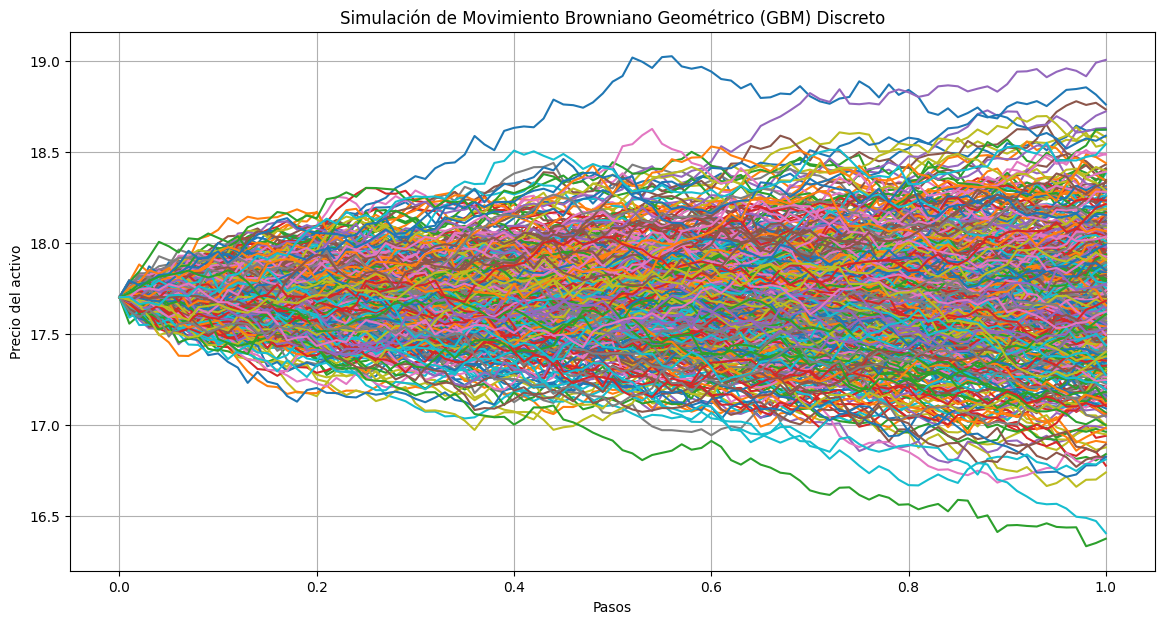

In [83]:
# Parámetros
T = 1.0  # Horizonte
N = 100  # Número de pasos
dt = T / N  # Tamaño del intervalo de tiempo
num_simulations = 500  # Número de simulaciones

# Inicializar la matriz de precios
S = np.zeros((num_simulations, N+1))
S[:, 0] = S0

# Generar las simulaciones
np.random.seed(42)  # Fijar la semilla para reproducibilidad. En caso de no querer poner como comentario esta línea
for i in range(num_simulations):
    epsilon = np.random.standard_normal(N)  # N valores aleatorios de una distribución normal estándar
    for t in range(1, N+1):
        S[i, t] = S[i, t-1] + S[i, t-1] * (mu * dt + sigma * epsilon[t-1] * np.sqrt(dt))

# Extraer los valores en el último paso
valores_ultimo_paso = S[:, -1]

# Graficar las trayectorias del precio
plt.figure(figsize=(14, 7))
for i in range(num_simulations):
    plt.plot(np.linspace(0, T, N+1), S[i])  # Sin transparencia para una visualización clara
plt.xlabel('Pasos')
plt.ylabel('Precio del activo')
plt.title('Simulación de Movimiento Browniano Geométrico (GBM) Discreto')
plt.grid(True)

__Realiza:__
1. Cálcula el VaR para 10 días con el método Monte Carlo.
1. Describe tus resultado como interpretarías el VaR de 10 dias con el método Monte Carlo.

Precio actual: 17.700000762939453
Media diaria: -1.7381007588016724e-05
Volatilidad diaria: 0.02130657913106163
VaR Monte Carlo a 10 días (95%): 1.8940426922551132


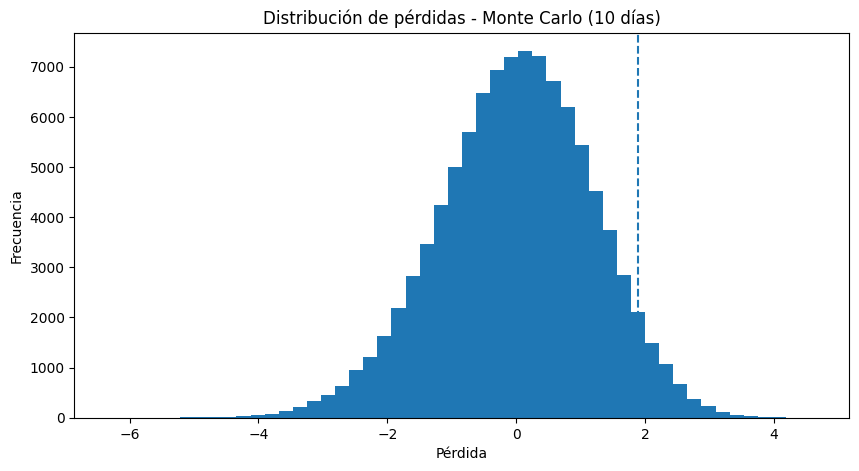

In [84]:
# Rendimientos logarítmicos
returns = np.log(prices / prices.shift(1)).dropna()

# Parámetros estimados
mu = returns.mean()
sigma = returns.std()
S0 = data["Adj Close"].iloc[-1]   # precio actual

# Parámetros de simulación
T = 10                 # horizonte de 10 días
N = 100000             # número de simulaciones
alpha = 0.95           # nivel de confianza

# Simular Z ~ N(0,1)
Z = np.random.normal(0, 1, N)

# Precio simulado al día 10 con GBM
ST = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# Pérdidas
losses = S0 - ST

# VaR al 95%  -> percentil 95 de pérdidas
VaR_10d = np.percentile(losses, 95)

print("Precio actual:", S0)
print("Media diaria:", mu)
print("Volatilidad diaria:", sigma)
print("VaR Monte Carlo a 10 días (95%):", VaR_10d)

# Histograma
plt.figure(figsize=(10,5))
plt.hist(losses, bins=50)
plt.axvline(VaR_10d, linestyle="dashed")
plt.title("Distribución de pérdidas - Monte Carlo (10 días)")
plt.xlabel("Pérdida")
plt.ylabel("Frecuencia")
plt.show()

Mediante el método de simulación Monte Carlo se obtuvo un VaR a 10 días de 1.8898 al 95% de confianza. Esto indica que existe un 95% de confianza de que la pérdida de la acción en un periodo de 10 días no excederá $1.8898 por acción. En otras palabras, solo en el 5% de los escenarios simulados la pérdida sería mayor a ese monto.